In [81]:
import matplotlib.pyplot as plt
import pandas as pd

In [64]:
df = pd.read_csv('../data/prepared/tmp.csv')

In [65]:
def set_group(x):
    
    if ((x >= 18) & (x <= 44)):
        return 'young age'
    
    if ((x >= 45) & (x <= 59)):
        return 'middle age'
    
    if ((x >= 60) & (x <= 74)):
        return 'elderly age'
    
    if ((x >= 75) & (x <= 89)):
        return 'senile age'
    
    if x >= 90:
        return 'long-livers'   

In [70]:
df['groups'] = df['Age'].apply(set_group)

In [71]:
df_cross_tab = pd.crosstab(df['groups'], df['Gender: F, M'], normalize=True)

In [72]:
index_sort = ['young age', 'middle age', 'elderly age', 'senile age', 'long-livers']

In [73]:
df['groups'].value_counts()

elderly age    246
senile age     132
middle age      69
young age       63
long-livers      2
Name: groups, dtype: int64

In [74]:
df_cross_tab = (df_cross_tab*100).round(2)

In [75]:
df_cross_tab = df_cross_tab.loc[index_sort]

In [76]:
df_cross_tab.columns = ['Female', 'Male']

In [77]:
df_cross_tab

,Female,Male
groups,,
young age,5.09,7.24
middle age,3.72,9.59
elderly age,16.44,31.70
senile age,9.98,15.85
long-livers,0.00,0.39


In [78]:


age = ["0-4", "5-9", "10-14", "15-19", "20-24", "25-29", "30-34", "35-39", "40-44", "45-49", "50-54", "55-59",
       "60-64", "65-69", "70-74", "75-79", "80-84", "85-89", "90+"]
male = [3, 3.3, 3.4, 3.2, 3, 3.3, 3.7, 3.9, 3.5, 3.1, 3.4, 2.8, 2.4, 2.1, 1.8, 1.4, 0.8, 0.4, 0.1]
female = [2.9, 3.1, 3.2, 3, 3, 3.4, 3.9, 4, 3.6, 3.2, 3.5, 2.9, 2.5, 2.3, 2.2, 2, 1.4, 0.9, 0.5]

population_df = pd.DataFrame({"Age": df_cross_tab.index, "Male": df_cross_tab['Male'], "Female": df_cross_tab['Female']})

population_df["Female_Left"] = 0
population_df["Female_Width"] = population_df["Female"]

population_df["Male_Left"] = -population_df["Male"]
population_df["Male_Width"] = population_df["Male"]

population_df

,Age,Male,Female,Female_Left,Female_Width,Male_Left,Male_Width
groups,,,,,,,
young age,young age,7.24,5.09,0,5.09,-7.24,7.24
middle age,middle age,9.59,3.72,0,3.72,-9.59,9.59
elderly age,elderly age,31.70,16.44,0,16.44,-31.70,31.70
senile age,senile age,15.85,9.98,0,9.98,-15.85,15.85
long-livers,long-livers,0.39,0.00,0,0.00,-0.39,0.39


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


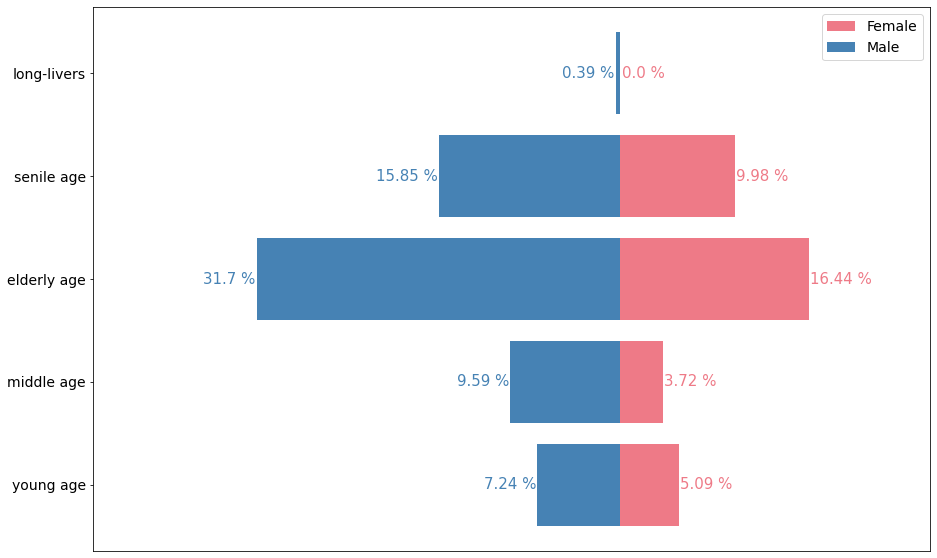

In [80]:
fig = plt.figure(figsize=(15,10))

plt.barh(y=population_df["Age"], width=population_df["Female_Width"], color="#ee7a87", label="Female");
plt.barh(y=population_df["Age"], width=population_df["Male_Width"], left=population_df["Male_Left"],
         color="#4682b4", label="Male");

# plt.text(-5, 17, "Male", fontsize=25, fontweight="bold");
# plt.text(4, 17, "Female", fontsize=25, fontweight="bold");

for idx in range(len(population_df)):
    plt.text(x=population_df["Male_Left"][idx]-0.1, y=idx, s="{} %".format(population_df["Male"][idx]),
             ha="right", va="center",
             fontsize=15, color="#4682b4");
    plt.text(x=population_df["Female_Width"][idx]+0.1, y=idx, s="{} %".format(population_df["Female"][idx]),
             ha="left", va="center",
             fontsize=15, color="#ee7a87");

plt.xlim(-46, 27);
# plt.xticks(range(-7,8), ["{} %".format(i) for i in range(-7,8)]);
plt.tick_params(
    axis='x',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off
    top=False,         # ticks along the top edge are off
    labelbottom=False) # labels along the bottom edge are off

plt.legend(loc="best");
plt.yticks(fontsize=14)
plt.legend(fontsize=14)

# plt.xlabel("Percent (%)", fontsize=16, fontweight="bold")
# plt.ylabel("Age Range", fontsize=14)
# plt.title("US Population Pyramid Chart", loc="left", pad=20, fontsize=25, fontweight="bold");
plt.savefig('population_pyramid.eps', format='eps', dpi=200, bbox_inches='tight', pad_inches=0)